## 1. Dependencies and Imports


In [1]:
# Install dependencies
!pip install --upgrade pip
!pip install torch==2.4.0+cu121 torchvision==0.19.0+cu121 --index-url https://download.pytorch.org/whl/cu121
!pip install transformers==4.44.0 huggingface-hub==0.24.0 pillow numpy opencv-python open3d ipympl rerun-sdk[notebook]

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
# Import required libraries
import os
from typing import Dict, List, Optional, Tuple
import cv2
import numpy as np
from PIL import Image
import torch
from tqdm.notebook import tqdm

## 2. Configuration


## 3. Execution Functions

These functions orchestrate the different parts of the pipeline:

## 4. SAM Proposal Generation
Implement the TODOs below

In [3]:
def generate_sam_proposals(image: Image.Image,
                          sam_model,
                          sam_processor,
                          device: str,
                          grid_size: int = 6,
                          confidence_threshold: float = 0.5) -> List[Dict]:
    """Generate object proposals using SAM with a grid of point prompts."""
    width, height = image.size
    
    # Generate grid of point prompts
    x_points = np.linspace(width * 0.1, width * 0.9, grid_size)
    y_points = np.linspace(height * 0.1, height * 0.9, grid_size)
    
    proposals = []
    processed_masks = []
    
    tqdm.write(f"Generating SAM proposals with {grid_size}x{grid_size} grid...")
    
    for i, x in enumerate(x_points):
        for j, y in enumerate(y_points):
            input_points = [[[x, y]]]
            
            try:
                inputs = sam_processor(
                    images=image,
                    input_points=input_points,
                    return_tensors="pt"
                )
                
                inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v 
                         for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = sam_model(**inputs)
                
                masks = sam_processor.image_processor.post_process_masks(
                    outputs.pred_masks.cpu(),
                    inputs["original_sizes"].cpu(),
                    inputs["reshaped_input_sizes"].cpu()
                )
                
                batch_masks = masks[0]
                if len(batch_masks) == 0:
                    continue
                
                point_masks = batch_masks[0]
                if len(point_masks) == 0:
                    continue
                
                best_mask_idx = 0
                best_score = 0.0

                if hasattr(outputs, 'iou_scores') and outputs.iou_scores is not None:
                    try:
                        # Extract IoU scores for [batch 0, point 0, all masks]
                        iou_scores = outputs.iou_scores[0, 0, :].cpu().numpy()

                        if len(iou_scores) > 0:
                            best_mask_idx = int(np.argmax(iou_scores))
                            best_score = float(np.max(iou_scores))

                            # Skip if below threshold
                            if best_score < confidence_threshold:
                                continue
                    except Exception as e:
                        tqdm.write(f"IoU extraction failed: {e}")
                        best_mask_idx = 0
                        best_score = 0.0

                
                mask = point_masks[best_mask_idx]
                
                if isinstance(mask, torch.Tensor):
                    mask_np = mask.cpu().numpy().astype(bool)
                else:
                    mask_np = np.array(mask).astype(bool)
                
                # Check for duplicates
                is_duplicate = False
                for existing_mask in processed_masks:
                    overlap = np.sum(mask_np & existing_mask)
                    union = np.sum(mask_np | existing_mask)
                    if union > 0 and overlap / union > 0.8:
                        is_duplicate = True
                        break
                
                if not is_duplicate and np.sum(mask_np) > 100:
                    proposals.append({
                        'mask': mask_np,
                        'area': np.sum(mask_np),
                        'point': [x, y],
                        'confidence': best_score
                    })
                    processed_masks.append(mask_np)
                    
            except Exception as e:
                continue
    
    tqdm.write(f"Generated {len(proposals)} unique segment proposals")
    return proposals

In [4]:
# Embodied AI project code
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from typing import Tuple
from transformers import (
    SamModel,
    SamProcessor,
)


def load_sam_model(model_size: str = "base", device: str = None) -> Tuple:
    """
    Load SAM model from Hugging Face using transformers.

    Args:
        model_size: Model size - 'base', 'large', 'huge'
        device: Device to use (cuda/cpu)

    Returns:
        Tuple of (model, processor, device)
    """
    print(f"Loading SAM model ({model_size})...")

    # Model configurations from HuggingFace
    model_configs = {
        'base': 'facebook/sam-vit-base',
        'large': 'facebook/sam-vit-large',
        'huge': 'facebook/sam-vit-huge'
    }

    model_id = model_configs.get(model_size, model_configs['base'])

    processor = SamProcessor.from_pretrained(model_id)
    model = SamModel.from_pretrained(model_id)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    model = model.to(device)
    model.eval()

    print(f"SAM model loaded on device: {device}")
    return model, processor, str(device)


def visualize_sam_grid_proposals(image: np.ndarray, proposals: list):
    """
    Visualize all the final SAM proposals (after IoU filtering and confidence thresholding).
    Each proposal should have keys: ['mask', 'area', 'point', 'confidence'].
    """
    if len(proposals) == 0:
        print("⚠️ No proposals to visualize.")
        return

    # Convert to RGB if grayscale
    if len(image.shape) == 2 or image.shape[2] == 1:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')

    # Sort by area (larger first)
    proposals_sorted = sorted(proposals, key=lambda x: x['area'], reverse=True)

    for proposal in proposals_sorted:
        mask = proposal['mask']
        conf = proposal.get('confidence', 0.0)
        point = proposal.get('point', [0, 0])

        # Random transparent color
        color_mask = np.random.random(3)
        color = np.concatenate([color_mask, [0.5]])  # RGBA

        # Create overlay
        overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
        overlay[mask] = color

        plt.imshow(overlay)

        # Optionally mark the grid point
        plt.scatter(point[0], point[1], c=[color_mask], marker='x', s=40)
        plt.text(point[0] + 5, point[1] + 5, f"{conf:.2f}", color='white', fontsize=8)

    plt.title(f"Grid-based SAM Proposals ({len(proposals)} masks)")
    plt.show()

/home/jovyan/SAM_final_project/venv/lib/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Loading SAM model (base)...
SAM model loaded on device: cuda
Generating SAM proposals with 10x10 grid...
Generated 41 unique segment proposals


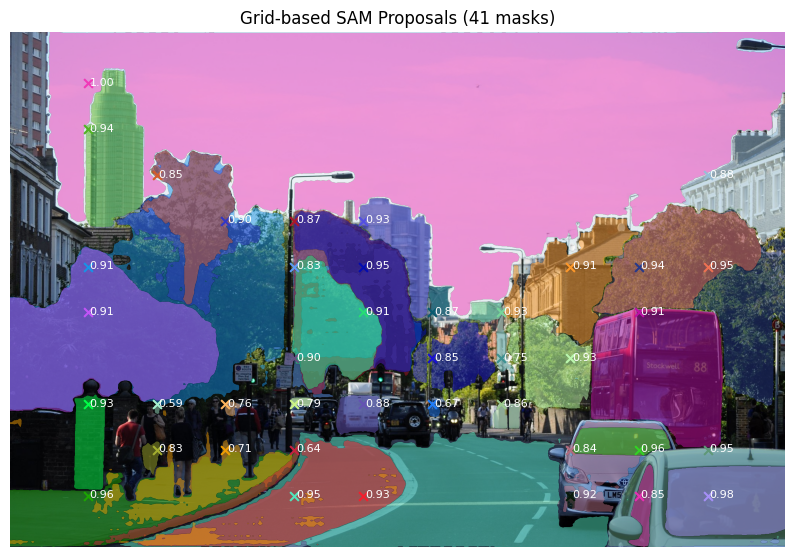

In [5]:
image = Image.open("demo01.jpg").convert("RGB")
sam_model, sam_processor, device = load_sam_model(model_size='base')
proposals = generate_sam_proposals(
    image,
    sam_model,
    sam_processor,
    device,
    grid_size=10,
    confidence_threshold=0.5
)

# Convert PIL image → NumPy array for plotting
rgb_image = np.array(image)

# Visualize proposals
visualize_sam_grid_proposals(rgb_image, proposals)

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def visualize_mask_boundaries(image: np.ndarray, proposals: list):
    """
    Visualize the boundaries of SAM masks on the image.
    Each mask boundary is shown in a different color.
    
    Args:
        image: HxWx3 RGB image as numpy array (dtype=uint8)
        proposals: list of dicts with 'mask' key (boolean mask)
    """
    if len(proposals) == 0:
        print("⚠️ No masks to visualize.")
        return

    # Ensure image is uint8 for OpenCV
    if image.dtype != np.uint8:
        vis_image = (image * 255).astype(np.uint8)
    else:
        vis_image = image.copy()

    for i, proposal in enumerate(proposals):
        mask = proposal['mask'].astype(np.uint8)  # convert bool -> uint8

        # Find contours (boundaries)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Random color for each mask
        color = (int(np.random.randint(0, 255)),
                 int(np.random.randint(0, 255)),
                 int(np.random.randint(0, 255)))

        # Draw contours
        cv2.drawContours(vis_image, contours, -1, color, 2)  # thickness=2

    # Show with matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_image)
    plt.axis('off')
    plt.title(f"SAM Mask Boundaries ({len(proposals)} masks)")
    plt.show()


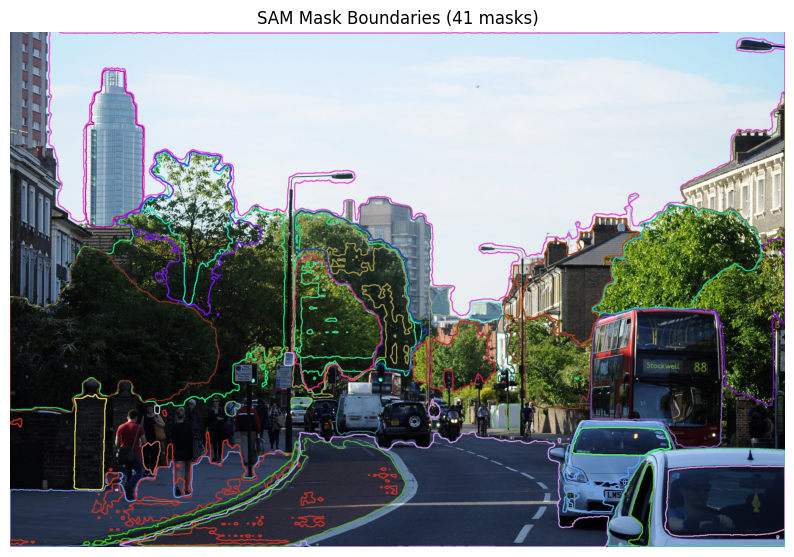

In [7]:
image = np.array(image)  # shape: H x W x 3, dtype: uint8
visualize_mask_boundaries(image, proposals)